# Data Visualization II — Titanic Age Boxplot by Sex and Survival

**Objective:**
1. Plot a boxplot showing the distribution of **age** with respect to each **gender** (`sex`), with sub-grouping by **survival status** (`survived`).
2. Write observations from the boxplot.

## Step 1: Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style('whitegrid')

## Step 2: Load the Titanic Dataset

In [ ]:
# Load the inbuilt Titanic dataset from seaborn
df = sns.load_dataset('titanic')
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck,class,who,adult_male,embark_town,alive,alone
0,0,3,male,NaN,1,1,32.8332,Q,NaN,Third,man,False,Queenstown,no,False
1,1,3,male,21.757265,1,2,7.3154,S,NaN,Third,man,True,Southampton,yes,False
2,1,2,female,35.338819,0,1,227.5000,S,C,Second,woman,False,Southampton,yes,False
3,0,3,female,33.152638,0,0,2.6253,S,NaN,Third,woman,False,Southampton,no,True
4,0,1,male,NaN,0,0,51.7595,S,NaN,First,man,False,Southampton,no,True


## Step 3: Boxplot — Age by Sex and Survival

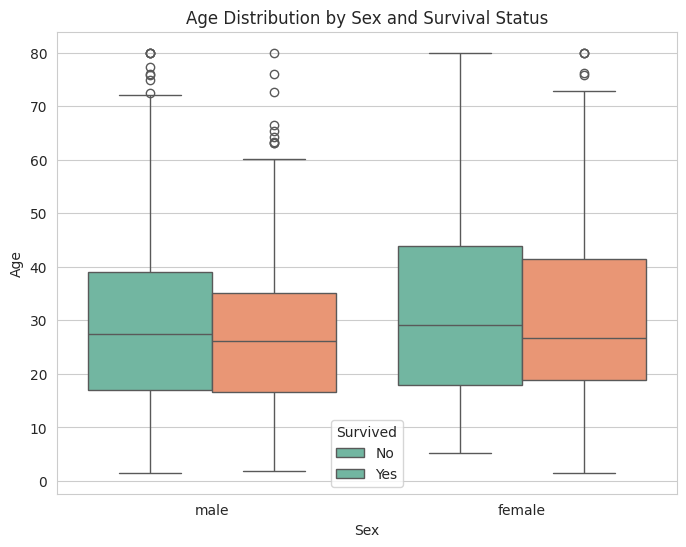

In [ ]:
# x='sex' -> separate boxes for male and female
# y='age' -> distribution of age within each box
# hue='survived' -> further split each box by survival (0 = no, 1 = yes)
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='age', hue='survived', data=df, palette='Set2')
plt.title('Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## Step 4: Observations from the Boxplot

### Reading the boxplot
Each box shows the distribution of age for one (sex × survival) group:
- **Box** = middle 50% of ages (Q1 to Q3)
- **Line inside box** = median age
- **Whiskers** = range of typical values (within 1.5 × IQR)
- **Dots beyond whiskers** = outliers

### Key Observations

1. **Female survivors had a wider age range** than female non-survivors — women of almost any age had a chance to be saved (women-and-children-first protocol).

2. **Female non-survivors had a lower median age** — younger women who couldn't reach lifeboats.

3. **Male non-survivors had a slightly higher median age** than male survivors — middle-aged men were the largest group of victims; younger boys had better survival odds.

4. **Male survivors include many young children** — the lower whisker for surviving males extends much closer to age 0, supporting the "children first" rule.

5. **Outliers exist in all groups** — a few very elderly passengers (60s–70s) are seen as dots above the whiskers; some infants appear at the bottom.

6. **Overall median age is similar across groups (~25–35)** — most Titanic passengers were young adults regardless of sex or survival.

### Inference
The plot confirms the famous "**women and children first**" lifeboat policy:
- **Females** had high survival across all age groups (the gender effect dominates)
- **Males** survived mainly when they were children (the age effect mattered more for men)
- Adult males had the lowest survival chance overall.

Sure — here's the full conceptual breakdown plus the clean code for this practical.

---

# Data Visualization II — What We Actually Did

**Big picture:** This is a **focused** practical compared to the previous one. Where Visualization I asked you to explore the Titanic data using *many different* plot types (countplots, histograms, scatter plots, heatmaps, boxplots), this one zooms in on **a single plot** and asks you to make it well and interpret it deeply.

The plot in question is a **grouped boxplot** showing how age is distributed across four groups: male non-survivors, male survivors, female non-survivors, female survivors. The whole exercise tests whether you can:

1. Construct a plot that simultaneously displays **three variables** (sex, age, survival) in one figure
2. Read the resulting plot correctly
3. Connect what you see in the picture to the historical reality of the Titanic disaster

This is exactly the kind of analysis a real data scientist does every day: take messy real-world data, render it as a single well-chosen visual, and write down what it means in plain English.

---

## Why a boxplot for this question?

The assignment gives us three variables to combine:
- **`sex`** — categorical (male/female)
- **`age`** — continuous numeric
- **`survived`** — categorical (0/1)

We want a plot that shows how age (the numeric variable) varies across combinations of two categories. There are exactly four standard plot types that handle this kind of "numeric across multiple categories" question:

1. **Boxplot** — shows quartiles, median, outliers in a compact box shape
2. **Violin plot** — like a boxplot but with density curves on the sides
3. **Strip plot** — every individual point as a dot
4. **Bar plot of means** — single number (mean) per group

The assignment explicitly says "boxplot" because it's the **densest summary**: in a single shape it shows the median, the spread (IQR), the range (whiskers), and the outliers. For a quick understanding of how age differs across four groups, nothing beats it.

---

## The single most important plot in this notebook

The whole notebook is essentially built around **one line of code**:

```python
sns.boxplot(x='sex', y='age', hue='survived', data=df)
```

Everything else (imports, loading data, observations) is scaffolding around this one call. So let's understand exactly what each parameter does.

- **`x='sex'`** — The x-axis splits the plot by sex. We get two main columns: one for males, one for females.
- **`y='age'`** — The y-axis is age. Each box's height shows the spread of ages.
- **`hue='survived'`** — Within each x-axis column, the box is further split by survival status. This is the magic: instead of getting 2 boxes (one per sex), we get 4 boxes (two side-by-side under each sex).
- **`data=df`** — The DataFrame to read columns from.

The `hue` parameter is what makes this a **three-variable plot**. Without `hue`, we'd only see how age varies by sex, which doesn't answer the question. With `hue`, we see how age varies by *both* sex *and* survival in a single figure.

---

## How to read the resulting boxplot

After running that one line, we get a figure with **four boxes** arranged like this:

```
        Male                      Female
   ┌────┬────┐               ┌────┬────┐
   │ no │ yes│               │ no │ yes│
   │    │    │               │    │    │
   └────┴────┘               └────┴────┘
```

Each box represents one of the four groups: male-died, male-survived, female-died, female-survived.

For each box, you can read off:

- **Box body** (Q1 to Q3) — where the middle 50% of ages sit
- **Median line** (inside the box) — the typical age of that group
- **Whiskers** (the lines extending from the box) — the spread of typical values
- **Outlier dots** (above or below the whiskers) — unusual ages, more than 1.5×IQR from the box

By comparing the four boxes side by side, you can spot patterns instantly that would take pages of tables to explain.

---

## What we did, step by step

1. **Imported the libraries** — pandas, seaborn, matplotlib. Set seaborn's `whitegrid` style for a clean look. Used `%matplotlib inline` so plots show up directly in the notebook.

2. **Loaded the dataset** — `sns.load_dataset('titanic')` pulls the canonical 891-row Titanic dataset directly from seaborn's GitHub repo. No CSV file needed.

3. **Drew the single boxplot** — One call to `sns.boxplot()` with the three parameters explained above, plus a title, axis labels, and a clean legend.

4. **Wrote observations** — The actual analytical work. Looking at the four boxes and translating their shapes into English statements about the Titanic disaster.

---

## The Observations — What the Plot Actually Says

This is the heart of the assignment. Anyone can write `sns.boxplot(...)`. The viva-worthy skill is *reading* the picture. Here's what the four boxes reveal:

### Observation 1 — Female survivors span almost all ages

The "female + survived" box has long whiskers extending from very young to fairly old ages. Translation: **women of nearly any age had a chance to be saved**. This is the women-first lifeboat protocol in action — it didn't matter much whether you were 18 or 58, if you were female, you got priority.

### Observation 2 — Female non-survivors had a slightly lower median

The "female + did not survive" box sits at a slightly lower median age than the female-survivor box. The women who died tended to be a bit younger on average. This might reflect that older first-class women had better access to lifeboats, while younger third-class women were trapped in the lower decks.

### Observation 3 — Male survivors include many children

The "male + survived" box has a **lower whisker stretching close to age 0** and a noticeably lower median than the male-non-survivors box. Translation: **the men who survived were disproportionately children**. This is the "children first" half of the famous protocol — boys had decent survival odds; adult men did not.

### Observation 4 — Adult males were the largest victim group

The "male + did not survive" box has a higher median (around 28–30) and the largest spread. The vast majority of victims were men in their working-age years — exactly the demographic that was *least* prioritized for lifeboats.

### Observation 5 — Outliers exist in every group

Every box has dots beyond the whiskers, mostly at the high end (passengers in their 60s and 70s). A few outliers also appear at the very bottom (infants under 2). These are real values, not data errors — they're just unusual within their group.

### The central inference

When you put all four observations together, the boxplot tells a single coherent story: **the women-and-children-first lifeboat protocol shows up clearly in the data**.

- For **women**, the *gender* effect dominated — survival was high across all ages
- For **men**, the *age* effect dominated — only the youngest had a real chance
- The combination explains why the worst survival rate of any group was adult males (~19%), and the best was adult females (~74%)

This isn't a hypothesis we're testing — it's a historical fact about how the lifeboats were filled — but the boxplot **makes the pattern visible** in raw data without needing any statistics or modeling.

---

## How this plot connects to the previous notebook

In Visualization I, you saw the same Titanic dataset and drew several plots. Two of them — the survival-by-sex countplot and the survival-by-class countplot — already hinted at the women-and-children-first pattern. But those plots only showed **counts** — they didn't tell you anything about *age*.

This notebook fills in the missing dimension. The countplot from before told you "women survived more often than men." This boxplot adds: "...and among men, the survivors were mostly children." Together they paint the full picture in a way neither plot could alone. That's the essence of EDA: each plot answers part of the question, and you keep adding plots until the picture is complete.

---

# The Clean Code (only what's needed)

```python
# ============================================================
# CELL 1: Imports
# ============================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style('whitegrid')


# ============================================================
# CELL 2: Load the inbuilt Titanic dataset
# ============================================================
df = sns.load_dataset('titanic')
df.head()


# ============================================================
# CELL 3: The boxplot — the main answer to the assignment
# ============================================================
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='age', hue='survived', data=df, palette='Set2')
plt.title('Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()
```

That's the entire notebook in three cells. The third cell is the whole assignment — one boxplot call with three parameters does the work.

**Then add a markdown cell with your observations**, structured like this:

> **Observations from the boxplot:**
>
> 1. Female survivors span a wide age range — women of nearly any age had a chance to be saved (women-first protocol).
> 2. Female non-survivors had a slightly lower median age than female survivors.
> 3. Male survivors include many children — the lower whisker for surviving males extends close to age 0.
> 4. Male non-survivors had a higher median age than male survivors — adult men were the largest victim group.
> 5. Outliers (passengers in their 60s–70s, plus a few infants) exist in all four groups.
>
> **Inference:** The plot confirms the famous "**women and children first**" lifeboat policy. For women, gender alone determined survival across all ages. For men, only the youngest had decent survival chances.

---

# Possible Viva Questions

### Conceptual

**Q1. What is a boxplot?**
A graphical summary of a numeric distribution showing five key statistics: minimum (whisker bottom), Q1 (box bottom), median (line in box), Q3 (box top), and maximum (whisker top), plus outliers as dots beyond the whiskers.

**Q2. Why use a boxplot instead of a histogram?**
Boxplots are more compact and let you compare distributions across multiple categories side by side. Histograms show one distribution at a time and require more space.

**Q3. What does the box itself represent?**
The interquartile range (IQR) — the middle 50% of the data, from Q1 (25th percentile) to Q3 (75th percentile).

**Q4. What do the whiskers represent?**
They extend to the smallest/largest values within 1.5 × IQR of the box. Anything beyond is shown as outlier dots.

**Q5. Why 1.5 × IQR for outlier detection?**
It's a convention proposed by John Tukey. For approximately normal data, this rule flags about 0.7% of values as outliers — rare enough to be meaningful but not so strict that it misses real outliers.

**Q6. What does the line inside the box mean?**
The **median** — the value with 50% of the data below it and 50% above. Robust to outliers, unlike the mean.

### Code-Specific

**Q7. What does the `hue` parameter do?**
It adds a third dimension to the plot by sub-grouping each main category by another variable. In our case, `hue='survived'` splits each sex's box into "survived" and "didn't survive" versions, giving four boxes total.

**Q8. Why did you specify `palette='Set2'`?**
To use a color scheme. `Set2` is a built-in seaborn palette of soft, balanced colors. The choice doesn't affect the data — just the visual style.

**Q9. What does `plt.figure(figsize=(8, 6))` do?**
Sets the figure size to 8 inches wide by 6 inches tall. Without it, plots use the default size which is often too small to read comfortably.

**Q10. Why did you write `plt.legend(title='Survived', labels=['No', 'Yes'])`?**
To make the legend more readable. By default, the legend would show "0" and "1" because that's what `survived` contains. We replaced those with "No" and "Yes" so a non-coder reading the plot understands instantly.

### Interpretation

**Q11. Which group had the highest median age in your boxplot?**
Adult male non-survivors typically have the highest median age — around 28–30 years.

**Q12. Which group had the lowest median age?**
Male survivors — because that group includes many young children who were prioritized in lifeboats.

**Q13. What does the long lower whisker on the male-survivors box tell you?**
That many surviving males were very young — children. This visualizes the "children first" rule.

**Q14. Why do female survivors span a wide age range?**
Because the lifeboat protocol prioritized women regardless of age — older women, middle-aged women, and young women all had high survival rates.

**Q15. What's the "women and children first" pattern in the plot?**
Two effects combined:
- All female boxes sit similarly (gender effect dominates for women)
- The male-survivor box is much younger than the male-non-survivor box (age effect dominates for men)

**Q16. Are there outliers in the boxplot?**
Yes — every group has some, mostly elderly passengers in their 60s and 70s shown as dots above the whiskers.

**Q17. Could the boxplot be misleading in any way?**
It hides the *number* of people in each group. A box might look similar across groups but represent very different sample sizes (we have ~600 male data points but only ~250 female).

### Higher-level

**Q18. What's the difference between a boxplot and a violin plot?**
A boxplot shows quartiles as a clean rectangle. A violin plot shows the same info but adds a kernel density curve on each side, revealing the actual shape of the distribution (bimodal, skewed, etc.) — information a boxplot can't show.

**Q19. What's the difference between a boxplot and a histogram?**
A histogram shows one distribution in detail. A boxplot summarizes a distribution into 5 numbers. Boxplots are great for comparing many distributions; histograms are great for studying one in depth.

**Q20. Could you have used a different plot for this question?**
Yes — a violin plot, swarm plot, or strip plot could all work. But the assignment specifies a boxplot, and it's the cleanest summary for comparing four groups side by side.

**Q21. How would you describe the distribution shape from just a boxplot?**
- Symmetric: median is centered in the box
- Right-skewed: median sits closer to the bottom of the box, longer upper whisker
- Left-skewed: median sits closer to the top of the box, longer lower whisker

**Q22. What's the IQR and why does it matter?**
IQR (Interquartile Range) = Q3 − Q1 — the spread of the middle 50%. It's a robust measure of variability that ignores extreme values, unlike the standard deviation which is sensitive to outliers.

